In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utility.utils import data_distribution_frame, model_selection_fig_dir, evaluate_model, plot_pr_curve, cross_val_scores_plot

from sklearn.model_selection import train_test_split, StratifiedKFold, LearningCurveDisplay
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegressionCV, SGDClassifier
from sklearn.dummy import DummyClassifier

np.random.seed(37)

In [2]:
data = pd.read_csv('../data/application_train.csv')

In [3]:
target = data['TARGET']
data.drop(columns=['TARGET'], inplace=True)

# Train-Test Split

In [4]:
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.66, shuffle=True, stratify=target, random_state=37)

In [5]:
print(f'data_train = {data_train.shape}')
print(f'target_train = {target_train.shape}')
print(f'data_test = {data_test.shape}')
print(f'target_test = {target_test.shape}')

data_train = (104553, 121)
target_train = (104553,)
data_test = (202958, 121)
target_test = (202958,)


In [6]:
data_distribution_frame(target_train)

,value counts,percent of total
0,96113,92%
1,8440,8%


In [7]:
data_distribution_frame(target_test)

,value counts,percent of total
0,186573,92%
1,16385,8%


# Preprocessing Pipelines

In [8]:
cat_columns = make_column_selector(dtype_include='object')(data_train)
num_columns = make_column_selector(dtype_exclude='object')(data_train)

In [9]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(sparse_output=False, handle_unknown='infrequent_if_exist', min_frequency=1)
)
cat_pipeline

,steps,"[('simpleimputer', ...), ('onehotencoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,categories,'auto'


In [10]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'), RobustScaler()
)
num_pipeline

,steps,"[('simpleimputer', ...), ('robustscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,with_centering,True


In [11]:
imputation_encoding = ColumnTransformer(transformers=[
    ('nums', num_pipeline, num_columns),
    ('cat_ohe', cat_pipeline, cat_columns),
], remainder='passthrough', n_jobs=-1)
imputation_encoding

,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [12]:
feature_reduction = make_pipeline(imputation_encoding, PCA(n_components=50, svd_solver='randomized', random_state=37))
feature_reduction

,steps,"[('columntransformer', ...), ('pca', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...), ('cat_ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Algorithms Spot-checking

## With Full Dimensions

In [13]:
dummy_clf_full =make_pipeline(imputation_encoding, DummyClassifier(strategy='most_frequent', random_state=37))
lr_clf_full =  make_pipeline(imputation_encoding, LogisticRegressionCV(solver='newton-cholesky', max_iter=300, scoring='average_precision', n_jobs=-1, random_state=37))
sgd_clf_full = make_pipeline(imputation_encoding, SGDClassifier(class_weight='balanced', n_jobs=-1, random_state=37))
rdf_clf_full = make_pipeline(imputation_encoding, RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=37))
hgb_clf_full = make_pipeline(imputation_encoding, HistGradientBoostingClassifier(class_weight='balanced', random_state=37))

### PR-AUC and F1-Score

In [14]:
dummy_clf_full_df = pd.DataFrame.from_dict(evaluate_model(dummy_clf_full, data_train, target_train), orient='columns')

In [15]:
lr_clf_full_df = pd.DataFrame.from_dict(evaluate_model(lr_clf_full, data_train, target_train), orient='columns')

In [16]:
sgd_clf_full_df = pd.DataFrame.from_dict(evaluate_model(sgd_clf_full, data_train, target_train), orient='columns')

In [17]:
rdf_clf_full_df = pd.DataFrame.from_dict(evaluate_model(rdf_clf_full, data_train, target_train), orient='columns')

In [18]:
hgb_clf_full_df = pd.DataFrame.from_dict(evaluate_model(hgb_clf_full, data_train, target_train), orient='columns')

In [19]:
model_scores_full = [dummy_clf_full_df, lr_clf_full_df, sgd_clf_full_df, rdf_clf_full_df, hgb_clf_full_df]
model_names_full = ['dummy_clf_full', 'lr_clf_full', 'sgd_clf_full', 'rdf_clf_full', 'hgb_clf_full']

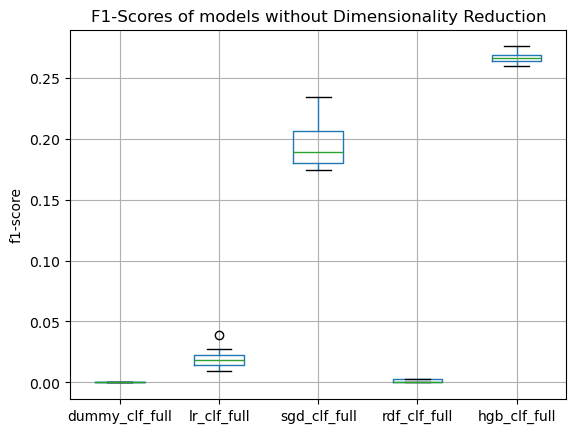

In [20]:
cross_val_scores_plot(model_scores_full, model_names_full, choice_column='f1-score')
plt.title('F1-Scores of models without Dimensionality Reduction')
plt.savefig(f"{model_selection_fig_dir}/full-cv-f1-scores.png")
plt.show()

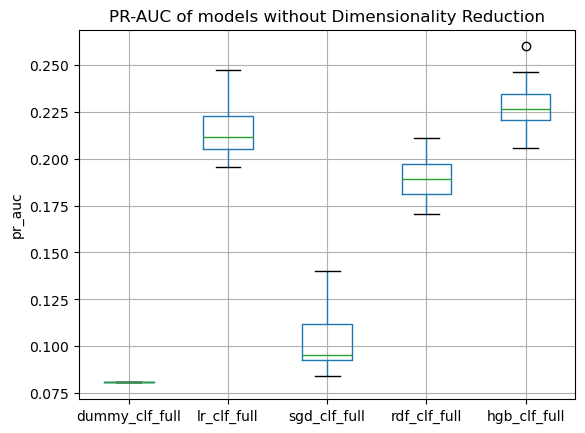

In [21]:
cross_val_scores_plot(model_scores_full, model_names_full, choice_column='pr_auc')
plt.title('PR-AUC of models without Dimensionality Reduction')
plt.savefig(f"{model_selection_fig_dir}/full-cv-pr-auc.png")
plt.show()

## With Reduced Dimensions

In [22]:
dummy_clf_reduced = make_pipeline(feature_reduction, DummyClassifier(strategy='most_frequent', random_state=37))
lr_clf_reduced =  make_pipeline(feature_reduction, LogisticRegressionCV(solver='newton-cholesky', max_iter=300, scoring='average_precision', n_jobs=-1, random_state=37))
sgd_clf_reduced = make_pipeline(feature_reduction, SGDClassifier(class_weight='balanced', n_jobs=-1, random_state=37))
rdf_clf_reduced = make_pipeline(feature_reduction, RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=37))
hgb_clf_reduced = make_pipeline(feature_reduction, HistGradientBoostingClassifier(class_weight='balanced', random_state=37))

### PR-AUC  and F1-Score

In [23]:
dummy_clf_reduced_df = pd.DataFrame.from_dict(evaluate_model(dummy_clf_reduced, data_train, target_train), orient='columns')

In [24]:
lr_clf_reduced_df = pd.DataFrame.from_dict(evaluate_model(lr_clf_reduced, data_train, target_train), orient='columns')

In [25]:
sgd_clf_reduced_df = pd.DataFrame.from_dict(evaluate_model(sgd_clf_reduced, data_train, target_train), orient='columns')

In [26]:
rdf_clf_reduced_df = pd.DataFrame.from_dict(evaluate_model(rdf_clf_reduced, data_train, target_train), orient='columns')

In [27]:
hgb_clf_reduced_df = pd.DataFrame.from_dict(evaluate_model(hgb_clf_reduced, data_train, target_train), orient='columns')

In [28]:
model_scores_reduced = [dummy_clf_reduced_df, lr_clf_reduced_df, sgd_clf_reduced_df, rdf_clf_reduced_df, hgb_clf_reduced_df]
model_names_reduced = ['dummy_clf_reduced', 'lr_clf_reduced', 'sgd_clf_reduced', 'rdf_clf_reduced', 'hgb_clf_reduced']

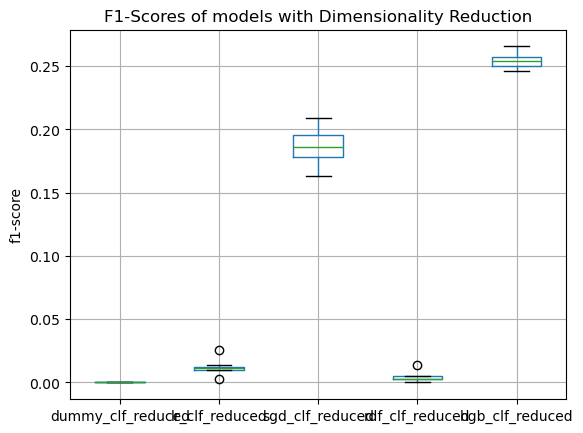

In [29]:
cross_val_scores_plot(model_scores_reduced, model_names_reduced, choice_column='f1-score')
plt.title('F1-Scores of models with Dimensionality Reduction')
plt.savefig(f"{model_selection_fig_dir}/reduced-cv-f1-scores.png")
plt.show()

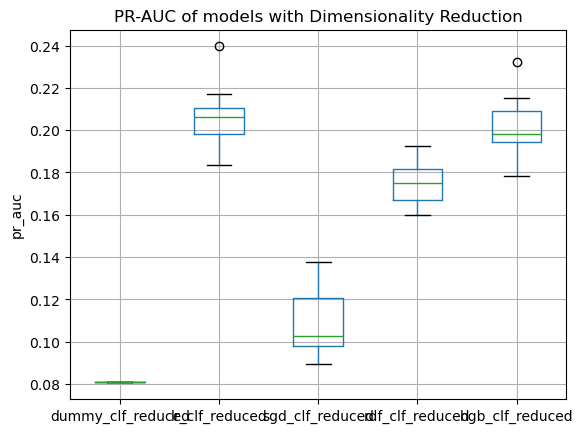

In [30]:
cross_val_scores_plot(model_scores_reduced, model_names_reduced, choice_column='pr_auc')
plt.title('PR-AUC of models with Dimensionality Reduction')
plt.savefig(f"{model_selection_fig_dir}/reduced-cv-pr-auc.png")
plt.show()

> From comparing the results obtained using dimensionality reduction and without dimensionality reduction, it can be seen that:
>
>  Other than the reduction in training time, Dimensionality Reduction offers no signifant performance advantage.
>
> Thus, the original full features of the data matrix will be used.

## Effect  of Training size

In [31]:
preprocessed_data = imputation_encoding.fit_transform(data_train)

> dummy_classifier (To serve as the performance benchmark): It is clearly underfitting and adding more data makes no improvement
> 
> logistic_regression: It shows promises of improvment in the presence of more data
> 
> stochastic_gradient_descent: It is clearly underfitting and adding more data makes no improvement
> 
> random_forest: It is clearly overfitting and adding more data makes no improvement
> 
> hist_gradient_boosting_classifier: It shows promises of improvment in the presence of more data
>
> Well performing algorithms choosen for hyperparameter tunning are:
> 1. Logistic Regression
>    
> 2. HistGradientBoostingClassifier

# Hyperparameter Tuning

In [32]:
outer_cv = StratifiedKFold(n_splits=5)
inner_cv = StratifiedKFold(n_splits=5)

In [33]:
lr_cv_model = LogisticRegressionCV(random_state=37)

lr_param_distributions = {
    'Cs': np.random.randint(1, 1e3, 10),
    'max_iter': np.random.randint(50, 500, 20),
    'tol': np.random.uniform(1e-7, 1e-2, 10),
}

lr_search = RandomizedSearchCV(
    estimator=lr_cv_model, n_iter=5,
    param_distributions=lr_param_distributions,
    scoring='average_precision', cv=inner_cv,
    n_jobs=-1, random_state=37, error_score='raise'
)

lr_cv_result = cross_validate(
        estimator=lr_search,
        X=preprocessed_data, y=target_train,
        cv=outer_cv, scoring={"f1": "f1", "pr_auc": "average_precision"},
        n_jobs=-1, error_score="raise", return_estimator=True
)


KeyboardInterrupt



In [ ]:
hgb_cv_model = HistGradientBoostingClassifier(class_weight='balanced', random_state=37)

hgb_param_distributions = {
    'learning_rate': np.random.uniform(1e-5, 1.0, 5),
    'max_iter': np.random.randint(10, 500, 10),
    'max_leaf_nodes': np.random.randint(20, 100, 10),
    'max_bins': np.random.randint(50, 255, 10),
    'n_iter_no_change': np.random.randint(5, 15, 5)
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_cv_model, n_iter=20,
    param_distributions=hgb_param_distributions,
    scoring='average_precision', cv=inner_cv,
    n_jobs=-1, random_state=37, error_score='raise'
)

hgb_cv_result = cross_validate(
        estimator=hgb_search,
        X=preprocessed_data, y=target_train,
        cv=outer_cv, scoring={"f1": "f1", "pr_auc": "average_precision"},
        n_jobs=-1, error_score="raise", return_estimator=True
)

In [ ]:
lr_cv_result = pd.DataFrame(mlp_cv_result)
lr_cv_result[['test_pr_auc', 'test_f1']].boxplot()
plt.title('LogisticRegressionCV_cv_result')
plt.show()

In [ ]:
hgb_cv_result_df = pd.DataFrame(hgb_cv_result)
hgb_cv_result_df[['test_pr_auc', 'test_f1']].boxplot()
plt.title('HistGradientBoostingClassifier_cv_result')
plt.show()

> The performance of Logistiic Regression is ---- fter a randomized search of parameters.
> 
> The performance of HistGradientBoostingClassifier is ---- fter a randomized search of parameters.

In [ ]:
for estimator in hgb_cv_result['estimator']:
    print(estimator.best_params_)

> BEST PARAMS (Consistent across all ten folds)
>
> n_iter_no_change = 
> 
> max_leaf_nodes = 
> 
> max_iter = 
> 
> max_bins = 
> 
> learning_rate =


## Selected Algorithm PR-Curve

In [ ]:
# hgb_pr_curve_model = HistGradientBoostingClassifier(
#     class_weight='balanced', random_state=37,
#     n_iter_no_change = 14, max_leaf_nodes = 20,
#     max_iter = 323, max_bins = 139,
#     learning_rate = 0.023863562745022885
# )

# plot_pr_curve(model=hgb_pr_curve_model, data=preprocessed_data, target=target_train, curve_label='HistGradientBoostingClassifier_PR_Curve')
# plt.savefig(f"{model_selection_fig_dir}/selected_algorithm_pr_curve.png")
# plt.show()